In [24]:
#!pip install scikit-learn pandas matplotlib
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [25]:
#путь к данным нужно заменить
data = pd.read_csv('/home/vadim/Edu/Numerical-methods-labs/lab-1/src/housing.csv', sep = ',')
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


В моем варианте test_size = 0.23, random_state = 45

In [26]:
#цель y столбец 14, "иксы" с 1 по 13
k = 13
X, y = data.drop([data.columns[k]],axis = 1), data[data.columns[k]]
#конструктор признаков
poly = PolynomialFeatures(1, include_bias = False, interaction_only = True)
#делим на трейн и тест
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.23, random_state = 45)
X_train, X_test = poly.fit_transform(X_train), poly.fit_transform(X_test)
X_train.shape, X_test.shape

((389, 13), (117, 13))

In [27]:
#скейлер сейчас "молчит"
scale = StandardScaler(with_mean = False, with_std = False)
#обучаем линейную модель (библиотечное решение)
model = LinearRegression(fit_intercept = False)
model = model.fit(X_train, y_train)
#средняя абсолютная ошибка при тестировании, коэффициент детерминации, число ненулевых
mean_absolute_error(model.predict(X_train),y_train), mean_absolute_error(model.predict(X_test),y_test)

(3.2216031104637786, 3.680407458138676)

In [28]:
#теоретически точное решение
a = np.linalg.inv((X_train.T)@X_train)@X_train.T@y_train
mean_absolute_error(X_train@a,y_train), mean_absolute_error(X_test@a,y_test)

(3.221603110463793, 3.6804074581387423)

In [29]:
np.linalg.cond(X_train.T @ X_train)

np.float64(72803306.78698574)

In [ ]:
test_size = 0.23

random_state = 45

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)


results = []





for scale in [False, True]:

    for degree in [1, 2, 3]:


        poly = PolynomialFeatures(degree, include_bias=False, interaction_only=True)

        X_train_poly = poly.fit_transform(X_train)

        X_test_poly = poly.transform(X_test)



    

        scaler = StandardScaler(with_mean=scale, with_std=scale)

        X_train_scaled = scaler.fit_transform(X_train_poly)

        X_test_scaled = scaler.transform(X_test_poly)





        model = LinearRegression(fit_intercept=False)

        model.fit(X_train_scaled, y_train)


    

        train_mae = mean_absolute_error(model.predict(X_train_scaled), y_train)

        test_mae = mean_absolute_error(model.predict(X_test_scaled), y_test)


        condition_number = np.linalg.cond(X_train_scaled.T @ X_train_scaled)




        results.append({

            'StandardScaler': scale,

            'PolynomialFeatures Degree': degree,

            'Train MAE': train_mae,

            'Test MAE': test_mae,

            'Condition Number': condition_number

        })


results_df = pd.DataFrame(results)
results_df

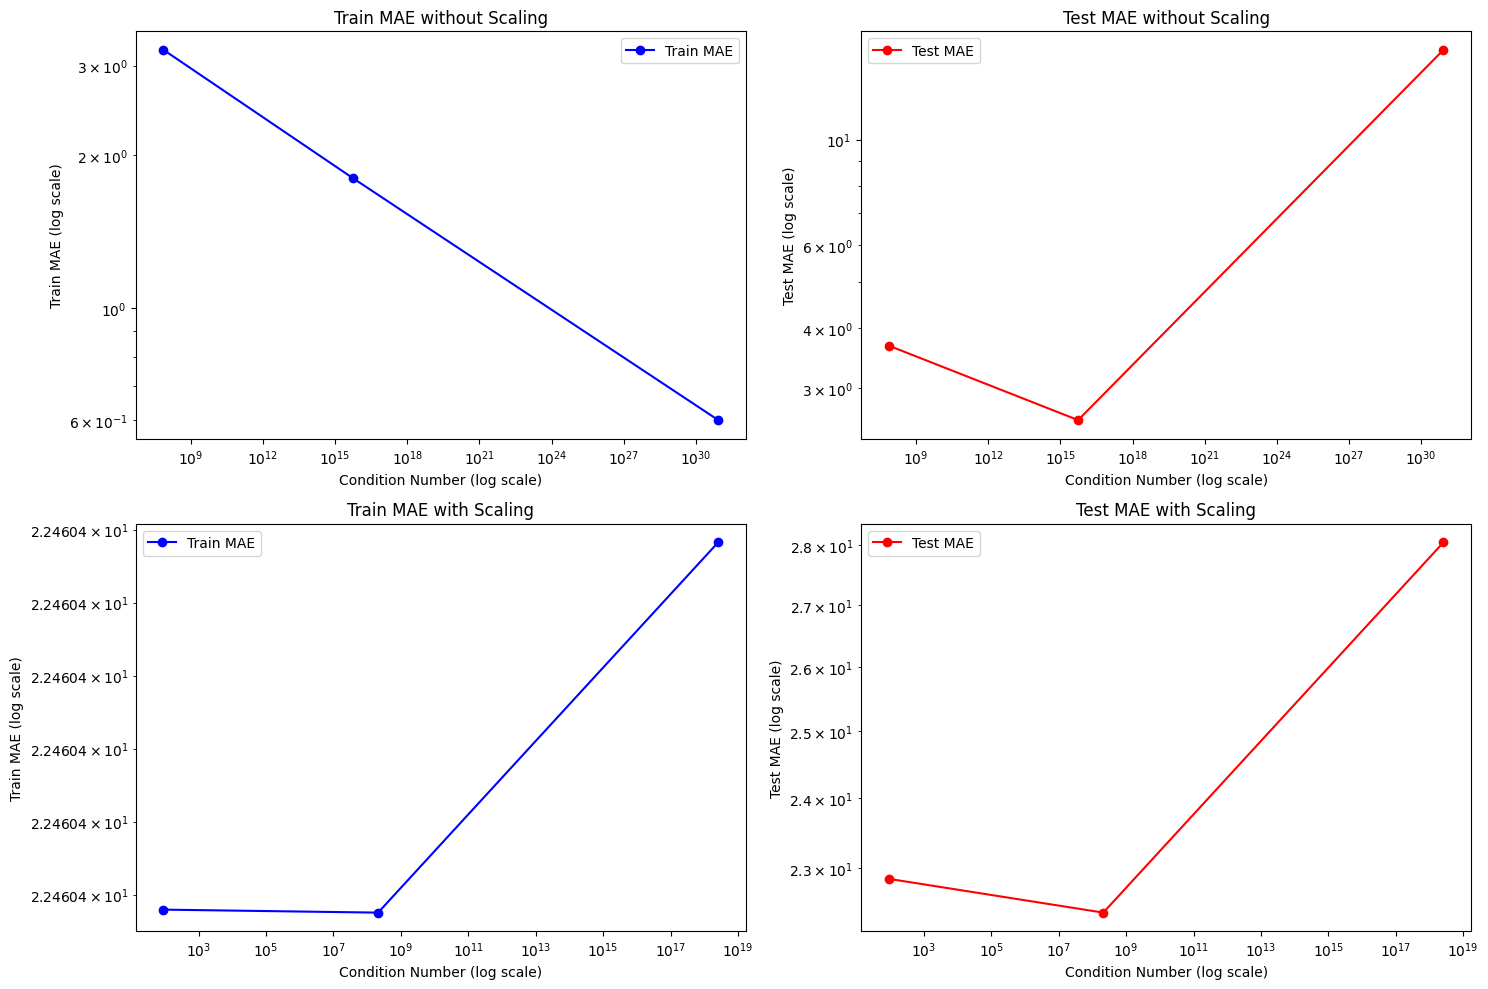

In [31]:


fig, ax = plt.subplots(2, 2, figsize=(15, 10))


no_scaling = results_df[results_df['StandardScaler'] == False]
with_scaling = results_df[results_df['StandardScaler'] == True]

no_scaling_sorted = no_scaling.sort_values(by='Condition Number')
with_scaling_sorted = with_scaling.sort_values(by='Condition Number')

ax[0, 0].plot(
    no_scaling_sorted['Condition Number'], no_scaling_sorted['Train MAE'],
    marker='o', linestyle='-', color='b', label='Train MAE'
)
ax[0, 0].set_xscale('log')
ax[0, 0].set_yscale('log')
ax[0, 0].set_xlabel('Condition Number (log scale)')
ax[0, 0].set_ylabel('Train MAE (log scale)')
ax[0, 0].set_title('Train MAE without Scaling')
ax[0, 0].legend()

ax[0, 1].plot(
    no_scaling_sorted['Condition Number'], no_scaling_sorted['Test MAE'],
    marker='o', linestyle='-', color='r', label='Test MAE'
)
ax[0, 1].set_xscale('log')
ax[0, 1].set_yscale('log')
ax[0, 1].set_xlabel('Condition Number (log scale)')
ax[0, 1].set_ylabel('Test MAE (log scale)')
ax[0, 1].set_title('Test MAE without Scaling')
ax[0, 1].legend()


ax[1, 0].plot(
    with_scaling_sorted['Condition Number'], with_scaling_sorted['Train MAE'],
    marker='o', linestyle='-', color='b', label='Train MAE'
)
ax[1, 0].set_xscale('log')
ax[1, 0].set_yscale('log')
ax[1, 0].set_xlabel('Condition Number (log scale)')
ax[1, 0].set_ylabel('Train MAE (log scale)')
ax[1, 0].set_title('Train MAE with Scaling')
ax[1, 0].legend()


ax[1, 1].plot(
    with_scaling_sorted['Condition Number'], with_scaling_sorted['Test MAE'],
    marker='o', linestyle='-', color='r', label='Test MAE'
)
ax[1, 1].set_xscale('log')
ax[1, 1].set_yscale('log')
ax[1, 1].set_xlabel('Condition Number (log scale)')
ax[1, 1].set_ylabel('Test MAE (log scale)')
ax[1, 1].set_title('Test MAE with Scaling')
ax[1, 1].legend()

plt.tight_layout()
plt.savefig('../docs/tex/graph.png', dpi = 600)
plt.show()